In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from scipy.ndimage import center_of_mass
import heapq
import random
from tqdm import tqdm
import heapq
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

## Importing and/or generating room layouts 

12x12 Kitchen island L room layout (1st test)

Cell 1: '12x12' Floorplan generated.


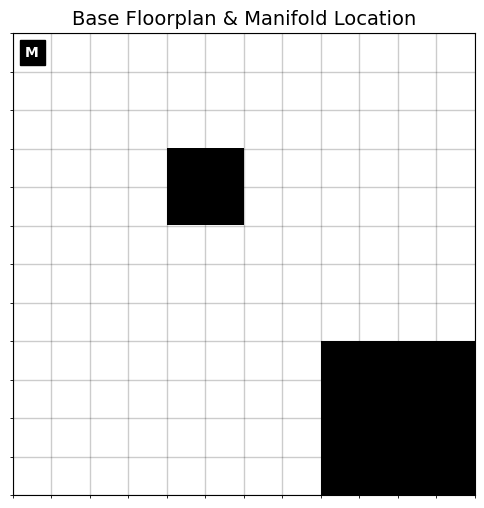

In [15]:
# ==========================================
# ROOM & MANIFOLD PARAMETERS
# ==========================================
MANIFOLD_POS = (0, 0) # (Row, Column)

def generate_floorplan(layout_type="complex"):
    """Generates a 12x12 grid environment. 0 = Walkable, -1 = Obstacle."""
    GRID_SIZE = 12
    grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int8)
    
    if layout_type == "complex":
        grid[3:5, 4:6] = -1  # Central Pillar
        grid[8:, 8:] = -1    # L-Shape Cutout
    elif layout_type == "island":
        grid[4:8, 4:8] = -1  # Massive Kitchen Island in the center
    elif layout_type == "simple":
        pass # Empty 12x12 room
        
    return grid

# Set up our working environment
room_grid = generate_floorplan("complex")
print(f"Cell 1: '{room_grid.shape[0]}x{room_grid.shape[1]}' Floorplan generated.")

#  Visualization 
fig, ax = plt.subplots(figsize=(6, 6))
vis_rgb = np.ones((room_grid.shape[0], room_grid.shape[1], 3)) 
vis_rgb[room_grid == -1] = [0, 0, 0] # Obstacles

ax.imshow(vis_rgb)

# Mark the Manifold
ax.plot(MANIFOLD_POS[1], MANIFOLD_POS[0], 's', color='black', markersize=18)
ax.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold')

ax.set_xticks(np.arange(-0.5, room_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, room_grid.shape[0], 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=1, alpha=0.2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Base Floorplan & Manifold Location", fontsize=14)
plt.show()

# House 24x24 layout 
tested for sectioning, disregard for now used in future scripts


In [12]:
# # ==========================================
# # CELL 1.2: WHOLE HOUSE ENVIRONMENT
# # ==========================================


# MANIFOLD_POS = (2, 2) # Inside the Top-Left Utility Room

# def generate_floorplan(layout_type="house"):
#     """Generates environments. 'house' is a 24x24 full floorplan."""
#     if layout_type == "house":
#         GRID_SIZE = 24
#         grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int8)
        
#         # 1. Main Interior Walls
#         grid[0:24, 8] = -1         # Main vertical dividing wall
#         grid[12, 8:24] = -1        # Horizontal wall splitting the right side
#         grid[10, 0:8] = -1         # Horizontal wall splitting the left side
        
#         # 2. Doorways (Cutting holes in the walls)
#         grid[10, 5:7] = 0          # Door to Top-Left Utility Room
#         grid[12, 14:17] = 0        # Wide double-door to Bottom-Right Room
#         grid[18:21, 8] = 0         # Hallway opening to Bottom-Left Room
        
#         # 3. Obstacles
#         grid[4:8, 14:18] = -1      # Large Kitchen Island in the Living Room
        
#         return grid
    
#     else:
#         # Fallback to the old 12x12
#         grid = np.zeros((12, 12), dtype=np.int8)
#         grid[3:5, 4:6] = -1
#         grid[8:, 8:] = -1
#         return grid

# # Set up our working environment
# room_grid = generate_floorplan("house")
# print(f"Cell 1: '{room_grid.shape[0]}x{room_grid.shape[1]}' Whole House Floorplan generated.")

# #  Visualization 
# fig, ax = plt.subplots(figsize=(8, 8))
# vis_rgb = np.ones((room_grid.shape[0], room_grid.shape[1], 3)) 
# vis_rgb[room_grid == -1] = [0.2, 0.2, 0.2] # Dark walls

# ax.imshow(vis_rgb)

# # Mark the Manifold
# ax.plot(MANIFOLD_POS[1], MANIFOLD_POS[0], 's', color='black', markersize=20)
# ax.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold')

# ax.set_xticks(np.arange(-0.5, room_grid.shape[1], 1), minor=True)
# ax.set_yticks(np.arange(-0.5, room_grid.shape[0], 1), minor=True)
# ax.grid(which="minor", color="#dddddd", linestyle='-', linewidth=1)
# ax.set_xticks([]); ax.set_yticks([])
# ax.set_title("Whole House Floorplan (24x24)", fontsize=16, pad=15)
# plt.show()

## Sectioning Lay -out into zones


Architect is sectioning the room...


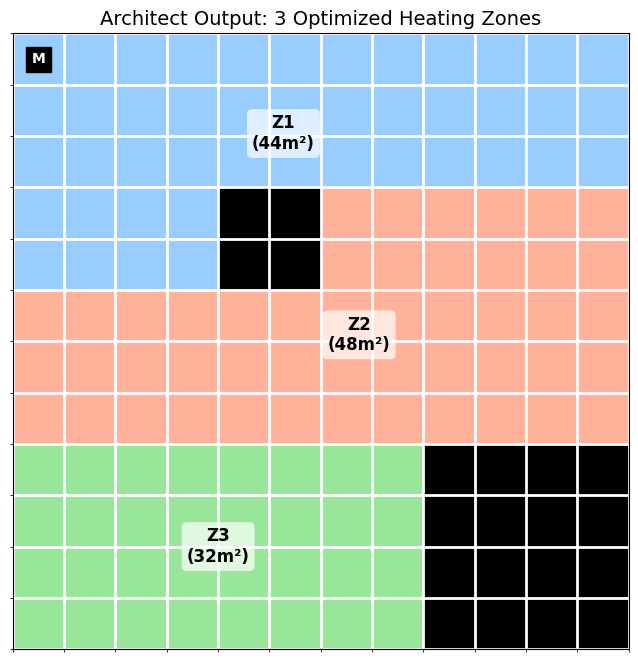

In [16]:
# ==========================================
# ARCHITECT PARAMETERS
# ==========================================
MIN_AREA_THRESHOLD = 15       
MAX_AREA_THRESHOLD = 60       
MAX_ABSORPTIONS_PER_ZONE = 1  

# ==========================================
# 1. CORE BSP ALGORITHM
# ==========================================
def get_bbox(mask):
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rmin, rmax, cmin, cmax

def is_perfect_rectangle(mask):
    if not np.any(mask): return False
    rmin, rmax, cmin, cmax = get_bbox(mask)
    return ((rmax - rmin + 1) * (cmax - cmin + 1)) == np.sum(mask)

def split_into_rectangles(mask, memo=None):
    if memo is None: memo = {}
    mask_bytes = mask.tobytes()
    if mask_bytes in memo: return memo[mask_bytes]

    if is_perfect_rectangle(mask): return [mask]

    rmin, rmax, cmin, cmax = get_bbox(mask)
    min_zones, best_splits = float('inf'), None

    for r in range(rmin, rmax):
        top, bot = mask.copy(), mask.copy()
        top[r+1:, :], bot[:r+1, :] = False, False
        if np.any(top) and np.any(bot):
            zones = split_into_rectangles(top, memo) + split_into_rectangles(bot, memo)
            if len(zones) < min_zones: min_zones, best_splits = len(zones), zones

    for c in range(cmin, cmax):
        left, right = mask.copy(), mask.copy()
        left[:, c+1:], right[:, :c+1] = False, False
        if np.any(left) and np.any(right):
            zones = split_into_rectangles(left, memo) + split_into_rectangles(right, memo)
            if len(zones) < min_zones: min_zones, best_splits = len(zones), zones

    memo[mask_bytes] = best_splits
    return best_splits

# ==========================================
# 2. MERGE FILTER 
# ==========================================
def get_neighbors_mask(mask):
    shifted = np.zeros_like(mask)
    shifted[:-1, :] |= mask[1:, :]
    shifted[1:, :] |= mask[:-1, :]
    shifted[:, :-1] |= mask[:, 1:]
    shifted[:, 1:] |= mask[:, :-1]
    return shifted

def optimize_zones(zones, min_area, max_area, max_absorptions):
    tracked_zones = [[z.copy(), 0] for z in zones]
    unmergeable = set()
    
    while True:
        areas = [np.sum(tz[0]) for tz in tracked_zones]
        eligible = [i for i, a in enumerate(areas) if a < min_area and i not in unmergeable]
        
        if not eligible: break
            
        target_idx = min(eligible, key=lambda i: areas[i])
        target_mask, _ = tracked_zones[target_idx]
        target_area = areas[target_idx]
        footprint = get_neighbors_mask(target_mask)
        
        best_neighbor, max_shared = -1, 0
        
        for i, (neighbor_mask, absorb_count) in enumerate(tracked_zones):
            if i == target_idx or absorb_count >= max_absorptions: continue 
            if areas[i] + target_area > max_area: continue
                
            shared = np.sum(footprint & neighbor_mask)
            if shared > max_shared:
                max_shared, best_neighbor = shared, i
            elif shared == max_shared and shared > 0:
                if areas[i] < areas[best_neighbor]: best_neighbor = i
                    
        if best_neighbor != -1:
            tracked_zones[best_neighbor][0] |= target_mask
            tracked_zones[best_neighbor][1] += 1
            tracked_zones.pop(target_idx)
            unmergeable.clear() 
        else:
            unmergeable.add(target_idx)

    return [tz[0] for tz in tracked_zones]

# ==========================================
# 3. EXECUTE & VISUALIZE
# ==========================================
print("Architect is sectioning the room...")
walkable = (room_grid == 0)
initial_zones = split_into_rectangles(walkable)

final_zones = optimize_zones(
    initial_zones, 
    MIN_AREA_THRESHOLD, 
    MAX_AREA_THRESHOLD, 
    MAX_ABSORPTIONS_PER_ZONE
)

# Render
fig, ax = plt.subplots(figsize=(8, 8))
vis_rgb = np.ones((room_grid.shape[0], room_grid.shape[1], 3)) 
vis_rgb[room_grid == -1] = [0, 0, 0]

colors = [[0.6, 0.8, 1.0], [1.0, 0.7, 0.6], [0.6, 0.9, 0.6], [0.9, 0.7, 0.9], [1.0, 0.9, 0.6]]

for i, mask in enumerate(final_zones):
    vis_rgb[mask] = colors[i % len(colors)]
    cy, cx = center_of_mass(mask)
    ax.text(cx, cy, f"Z{i+1}\n({np.sum(mask)}m²)", 
            color='black', fontsize=12, fontweight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

ax.imshow(vis_rgb)

# Mark the Manifold (Added here!)
ax.plot(MANIFOLD_POS[1], MANIFOLD_POS[0], 's', color='black', markersize=18, zorder=5)
ax.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold', zorder=6)

ax.set_xticks(np.arange(-0.5, room_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, room_grid.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Architect Output: {len(final_zones)} Optimized Heating Zones", fontsize=14)
plt.show()

## Zone Piping Layout: Evolutionairy Algorithm

NameError: name 'zone_results' is not defined

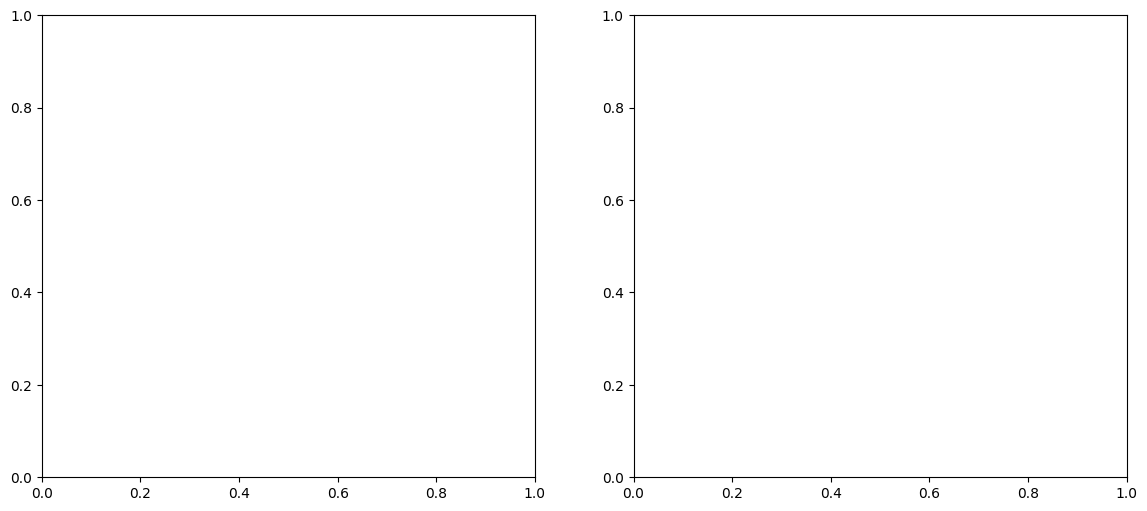

In [18]:
# ==========================================
# PLUMBER PARAMETERS
# ==========================================
MANIFOLD_POS = (0, 0)

# Evolution Parameters
POP_SIZE = 200
GENERATIONS = 400
BASE_MUTATION = 0.05
PANIC_MUTATION = 0.30

# Serpentine Weights
COVERAGE_REWARD = 500.0
TURNING_PENALTY = -500.0        # altered form -100 as per suggestion form weight sensitivity analysis 
CRASH_PENALTY = -2000.0

# ==========================================
# 1. DIJKSTRA & CORNER FINDING
# ==========================================
def find_zone_corners(zone_mask):
    """Identifies corners of a zone (tiles with 2 or fewer internal orthogonal neighbors)"""
    corners = []
    rows, cols = np.where(zone_mask)
    for r, c in zip(rows, cols):
        neighbors = 0
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < zone_mask.shape[0] and 0 <= nc < zone_mask.shape[1]:
                if zone_mask[nr, nc]:
                    neighbors += 1
        if neighbors <= 2:
            corners.append((r, c))
    return corners

def get_dijkstra_distance(grid, start, target):
    """Calculates the shortest walkable path from Start to Target"""
    if start == target: return 0
    queue = [(0, start)]
    visited = set([start])
    
    while queue:
        dist, (r, c) = heapq.heappop(queue)
        if (r, c) == target: return dist
        
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < grid.shape[0] and 0 <= nc < grid.shape[1]:
                if grid[nr, nc] == 0 and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    heapq.heappush(queue, (dist + 1, (nr, nc)))
    return float('inf') # Unreachable

# ==========================================
# 2. THE SERPENTINE DECODER
# ==========================================
def calculate_serpentine_fitness(dna_map, base_grid, zone_mask, start_pos):
    grid_size = dna_map.shape[0]
    
    # ISOLATE THE ZONE: Treat everything outside the zone as a Wall (visited = True)
    visited = np.ones((grid_size, grid_size), dtype=bool) 
    visited[zone_mask] = False  
    visited[base_grid == -1] = True # Double check hard obstacles
    
    current_pos = start_pos
    visited[current_pos] = True
    path_x, path_y = [current_pos[1]], [current_pos[0]]
    
    score = 1000.0 
    current_heading = None 
    distance_since_last_turn = 0 
    mistakes = 0
    
    while True:
        r, c = current_pos
        valid_neighbors = []
        for heading, (dr, dc) in enumerate([(-1,0), (0,1), (1,0), (0,-1)]): # N, E, S, W
            nr, nc = r + dr, c + dc
            if 0 <= nr < grid_size and 0 <= nc < grid_size:
                if not visited[nr, nc]:
                    valid_neighbors.append(((nr, nc), heading))
                    
        if not valid_neighbors: break
            
        # Neural/DNA Choice
        highest_priority = -1.0
        best_neighbor, best_heading = None, None
        for (nr, nc), heading in valid_neighbors:
            if dna_map[nr, nc] > highest_priority:
                highest_priority = dna_map[nr, nc]
                best_neighbor = (nr, nc)
                best_heading = heading

        # Serpentine Heuristics & Healing
        if current_heading is not None:
            if best_heading == current_heading:
                distance_since_last_turn += 1
                if distance_since_last_turn > 4 and mistakes > 0:
                    mistakes -= 1 # Heal 1 strike for good straight behavior
                    distance_since_last_turn = 0
            else:
                if distance_since_last_turn < 2:
                    score += TURNING_PENALTY # Penalty for zig-zagging
                distance_since_last_turn = 0
                
                # Turn Logic: 180 U-Turns break the pipe
                if abs(best_heading - current_heading) == 2:
                    score += CRASH_PENALTY
                    mistakes += 1
            
            if mistakes >= 3: break # Kill switch

        current_heading = best_heading
        current_pos = best_neighbor
        visited[current_pos] = True
        path_x.append(current_pos[1])
        path_y.append(current_pos[0])
        score += COVERAGE_REWARD 
        
    return int(score), path_x, path_y

# # ==========================================
# # 3. EVOLUTION ENGINE (ZONED)
# # ==========================================
# def run_zoned_evolution(base_grid, zone_mask, start_pos):
#     grid_size = base_grid.shape[0]
#     population = [np.random.rand(grid_size, grid_size) for _ in range(POP_SIZE)]
    
#     best_score, best_px, best_py = -9999, [], []
#     history = []
#     stagnation = 0 
    
#     # We use a smaller loop here for demonstration, you can increase GENERATIONS
#     pbar = tqdm(range(GENERATIONS), desc=f"Routing Zone")
#     for gen in pbar:
#         scored = []
#         for dna in population:
#             score, px, py = calculate_serpentine_fitness(dna, base_grid, zone_mask, start_pos)
#             scored.append((score, dna, px, py))
            
#         scored.sort(key=lambda x: x[0], reverse=True)
#         if scored[0][0] > best_score:
#             best_score, best_dna, best_px, best_py = scored[0][0], scored[0][1], scored[0][2], scored[0][3]
#             stagnation = 0 
#         else:
#             stagnation += 1 
            
#         history.append(best_score)
#         mutation_rate = PANIC_MUTATION if stagnation > 20 else BASE_MUTATION
        
#         # Breed next generation
#         parents = [s[1] for s in scored[:30]]
#         next_gen = parents[:5] # Bunker
        
#         if stagnation > 60:
#             next_gen.extend([np.random.rand(grid_size, grid_size) for _ in range(POP_SIZE - 5)])
#             stagnation = 0
#         else:
#             while len(next_gen) < POP_SIZE:
#                 p1, p2 = random.choice(parents), random.choice(parents)
#                 mask = np.random.rand(grid_size, grid_size) > 0.5
#                 child = np.where(mask, p1, p2)
#                 mut_mask = np.random.rand(grid_size, grid_size) < mutation_rate
#                 child = np.where(mut_mask, np.random.rand(grid_size, grid_size), child)
#                 next_gen.append(child)
                
#         population = next_gen
        
#     return best_score, best_px, best_py, history

# ==========================================
# 3. EVOLUTION ENGINE (ZONED) - SWAP MUTATION
# ==========================================


def run_zoned_evolution(base_grid, zone_mask, start_pos):
    grid_size = base_grid.shape[0]
    population = [np.random.rand(grid_size, grid_size) for _ in range(POP_SIZE)]
    
    best_score, best_px, best_py = -9999, [], []
    history = []
    stagnation = 0 
    
    pbar = tqdm(range(GENERATIONS), desc=f"Routing Zone")
    for gen in pbar:
        scored = []
        for dna in population:
            score, px, py = calculate_serpentine_fitness(dna, base_grid, zone_mask, start_pos)
            scored.append((score, dna, px, py))
            
        scored.sort(key=lambda x: x[0], reverse=True)
        if scored[0][0] > best_score:
            best_score, best_dna, best_px, best_py = scored[0][0], scored[0][1], scored[0][2], scored[0][3]
            stagnation = 0 
        else:
            stagnation += 1 
            
        history.append(best_score)
        
        # 1. Smooth Stagnation Ramp
        mutation_rate = min(PANIC_MUTATION, BASE_MUTATION + (stagnation * 0.005))
        
        # Breed next generation
        parents = [s[1] for s in scored[:30]]
        next_gen = parents[:5] # Bunker (Protect top 5)
        
        if stagnation > 0: 
            # Total reset if hopelessly stuck
            next_gen.extend([np.random.rand(grid_size, grid_size) for _ in range(POP_SIZE - 5)])
            stagnation = 0
        else:
            while len(next_gen) < POP_SIZE:
                p1, p2 = random.choice(parents), random.choice(parents)
                
                # Crossover
                mask = np.random.rand(grid_size, grid_size) > 0.5
                # Use .copy() to prevent modifying the parent DNA during swapping
                child = np.where(mask, p1, p2).copy() 
                
                # 2. Swap Mutation (Discrete Ranking Change)
                # Calculate how many swaps to perform based on mutation rate and grid size
                num_swaps = int((grid_size * grid_size) * mutation_rate * 0.1) 
                if num_swaps < 1: num_swaps = 1

                for _ in range(num_swaps):
                    # Pick a random cell
                    r1 = random.randint(0, grid_size - 1)
                    c1 = random.randint(0, grid_size - 1)
                    
                    # Pick a random adjacent direction (N, S, E, W)
                    dr, dc = random.choice([(-1,0), (1,0), (0,-1), (0,1)])
                    r2, c2 = r1 + dr, c1 + dc
                    
                    # Ensure the neighbor is within grid bounds before swapping
                    if 0 <= r2 < grid_size and 0 <= c2 < grid_size:
                        child[r1, c1], child[r2, c2] = child[r2, c2], child[r1, c1]
                
                next_gen.append(child)
                
        population = next_gen
        
    return best_score, best_px, best_py, history


# ==========================================
# 4. EXECUTE PIPELINE PER ZONE
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Define our consistent color palette first
colors = ['blue', 'red', 'green', 'purple', 'orange']

# Plot 1: Combined Learning Curves (Now matching zone colors)
for i, res in enumerate(zone_results):
    ax1.plot(res['history'], 
             color=colors[i % len(colors)], # Matches the line color to the array
             label=f"Zone {res['zone_id']} (Score: {res['score']})", 
             linewidth=2)
ax1.set_title("Evolutionary Learning Curves per Zone")
ax1.set_xlabel("Generation"); ax1.set_ylabel("Score")
ax1.legend(); ax1.grid(True)

# Plot 2: The Global Pipe Layout
grid_h, grid_w = room_grid.shape 
vis_rgb = np.ones((grid_h, grid_w, 3)) 
vis_rgb[room_grid == -1] = [0, 0, 0] # Obstacles
ax2.imshow(vis_rgb)

for i, res in enumerate(zone_results):
    ax2.plot(res['px'], res['py'], 
             color=colors[i % len(colors)], # Uses the exact same array
             linewidth=3, marker='o', markersize=4, 
             label=f"Zone {res['zone_id']} Pipe")

# Mark the Manifold
ax2.plot(MANIFOLD_POS[1], MANIFOLD_POS[0], 's', color='black', markersize=15)
ax2.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold')

ax2.set_xticks(np.arange(-0.5, grid_w, 1), minor=True)
ax2.set_yticks(np.arange(-0.5, grid_h, 1), minor=True)
ax2.grid(which="minor", color="black", linestyle='-', linewidth=1, alpha=0.2)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title("Global Zoned Serpentine Layout")
ax2.legend(loc='lower right', fontsize=8)

plt.show()

## Full Layout of Floor Heating Pipes
#### Connecting the Manifold to all the zones starting positions

In [19]:
# ==========================================
# CELL 4: GLOBAL HIGHWAY & COUNTERFLOW PIPING
# ==========================================


# 1. Wall-Hugging Dijkstra for the Highway
def get_wall_hugging_path(grid, start, end):
    queue = [(0, start, [start])]
    visited = set([start])
    
    while queue:
        cost, curr, path = heapq.heappop(queue)
        if curr == end: return path
        
        r, c = curr
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < grid.shape[0] and 0 <= nc < grid.shape[1] and grid[nr, nc] == 0:
                if (nr, nc) not in visited:
                    visited.add((nr, nc))
                    
                    is_wall = False
                    for ddr, ddc in [(-1,0), (1,0), (0,-1), (0,1)]:
                        nnr, nnc = nr+ddr, nc+ddc
                        if nnr < 0 or nnr >= grid.shape[0] or nnc < 0 or nnc >= grid.shape[1] or grid[nnr, nnc] == -1:
                            is_wall = True
                            
                    step_cost = 1 if is_wall else 10
                    heapq.heappush(queue, (cost + step_cost, (nr, nc), path + [(nr, nc)]))
    return []

# 2. Path Cleaner (Removes duplicate points that break vector math)
def clean_path(px, py):
    cx, cy = [px[0]], [py[0]]
    for i in range(1, len(px)):
        if px[i] != cx[-1] or py[i] != cy[-1]:
            cx.append(px[i])
            cy.append(py[i])
    return cx, cy

# 3. Dynamic Mitered Double Pipe (Handles variable spacing & U-Turns)
def get_dynamic_mitered_pipe(px, py, c_offs, p_spaces):
    n = len(px)
    sx, sy, rx, ry = np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n)
    
    for i in range(n):
        if i == 0:
            dx, dy = px[1]-px[0], py[1]-py[0]
        elif i == n-1:
            dx, dy = px[-1]-px[-2], py[-1]-py[-2]
        else:
            dx1, dy1 = px[i]-px[i-1], py[i]-py[i-1]
            dx2, dy2 = px[i+1]-px[i], py[i+1]-py[i]
            dx, dy = (dx1 + dx2) / 2.0, (dy1 + dy2) / 2.0
            
        l = np.hypot(dx, dy)
        
        if l == 0:
            # FIX: Fallback for 180-degree U-turns to prevent pinched corruption
            l_fallback = np.hypot(dx1, dy1)
            nx, ny = (-dy1/l_fallback, dx1/l_fallback) if l_fallback > 0 else (0, 0)
        else:
            nx, ny = -dy/l, dx/l 
            
        if i > 0 and i < n-1 and l < 0.99 and l > 0:
            nx /= l
            ny /= l
            
        off_s = c_offs[i] + p_spaces[i]
        off_r = c_offs[i] - p_spaces[i]
            
        sx[i] = px[i] + nx * off_s
        sy[i] = py[i] + ny * off_s
        rx[i] = px[i] + nx * off_r
        ry[i] = py[i] + ny * off_r
        
    return sx, sy, rx, ry

# ==========================================
# EXECUTE: CONNECT HIGHWAYS & RENDER
# ==========================================
print("Calculating Dynamic Wall-Hugging Highways...")

for res in zone_results:
    start_r, start_c = res['py'][0], res['px'][0]
    hw_path = get_wall_hugging_path(room_grid, MANIFOLD_POS, (start_r, start_c))
    
    hw_px = [c for r,c in hw_path]
    hw_py = [r for r,c in hw_path]
    
    # Combine Highway + Zone, then clean duplicates
    full_px, full_py = clean_path(hw_px + res['px'][1:], hw_py + res['py'][1:])
    
    res['full_px'] = full_px
    res['full_py'] = full_py
    res['hw_dist'] = len(hw_path)
    # Track the exact index where the highway ends and the zone begins
    res['zone_start_idx'] = len(hw_px) - 1 

zone_results.sort(key=lambda x: x['hw_dist'])

#  MASTER VISUALIZATION (CAD STYLE) 
fig, ax = plt.subplots(figsize=(10, 10))

vis_grid = np.zeros_like(room_grid, dtype=float)
vis_grid[room_grid == 0] = 1.0   
vis_grid[room_grid == -1] = 0.2  
ax.imshow(vis_grid, cmap='gray', vmin=0, vmax=1)

grid_size = room_grid.shape[0]
ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.set_xticks([]); ax.set_yticks([])

zone_colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e']

for i, res in enumerate(zone_results):
    lane_offset = 0.12 + (i * 0.15) 
    
    n = len(res['full_px'])
    c_offs = np.zeros(n)
    p_spaces = np.zeros(n)
    
    # DYNAMIC SPACING LOGIC
    for j in range(n):
        if j == 0:
            c_offs[j] = 0.0          # Converge into exact center of manifold
            p_spaces[j] = 0.05       # Tight spacing
        elif j <= res['zone_start_idx']:
            c_offs[j] = lane_offset  # Shift to dedicated Highway lane
            p_spaces[j] = 0.05       # Tightly packed (Transport mode)
        else:
            c_offs[j] = 0.0          # Centered in the 1x1m cell
            p_spaces[j] = 0.25       # Wide spacing (Heating mode)
            
    sx, sy, rx, ry = get_dynamic_mitered_pipe(res['full_px'], res['full_py'], c_offs, p_spaces)
    
    c_zone = zone_colors[i % len(zone_colors)]
    
    sup_segs, ret_segs = [], []
    for j in range(n - 1):
        sup_segs.append([(sx[j], sy[j]), (sx[j+1], sy[j+1])])
        ret_segs.append([(rx[j], ry[j]), (rx[j+1], ry[j+1])])
        
    sup_segs.append([(sx[-1], sy[-1]), (rx[-1], ry[-1])])

    ax.add_collection(LineCollection(sup_segs, colors=c_zone, linewidths=3.5, capstyle='round', joinstyle='round'))
    ax.add_collection(LineCollection(ret_segs, colors=c_zone, linewidths=3.5, capstyle='round', joinstyle='round'))

ax.scatter(MANIFOLD_POS[1], MANIFOLD_POS[0], color='black', s=450, marker='s', zorder=10)
ax.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold', zorder=11)

ax.set_title("Final Zoned Counterflow (double) Serpentine Piping System", fontsize=16, pad=15)
plt.show()

Calculating Dynamic Wall-Hugging Highways...


NameError: name 'zone_results' is not defined

# Sensitivty Analysis 
### weight sensitivty

Starting Multi-Seed Sensitivity Analysis (10 runs per profile) over 150 generations...

 Testing Profile: Baseline (Original Weights) 


Routing Zone: 100%|██████████| 150/150 [00:03<00:00, 47.73it/s]


Routing Zone: 100%|██████████| 150/150 [00:03<00:00, 48.68it/s]


Routing Zone: 100%|██████████| 150/150 [00:03<00:00, 48.15it/s]


Routing Zone: 100%|██████████| 150/150 [00:02<00:00, 50.91it/s]


...

Routing Zone: 100%|██████████| 150/150 [00:02<00:00, 51.87it/s]


Routing Zone: 100%|██████████| 150/150 [00:02<00:00, 50.22it/s]


Routing Zone: 100%|██████████| 150/150 [00:02<00:00, 52.15it/s]


Routing Zone: 100%|██████████| 150/150 [00:02<00:00, 50.67it/s]


Run 10/10 completed.


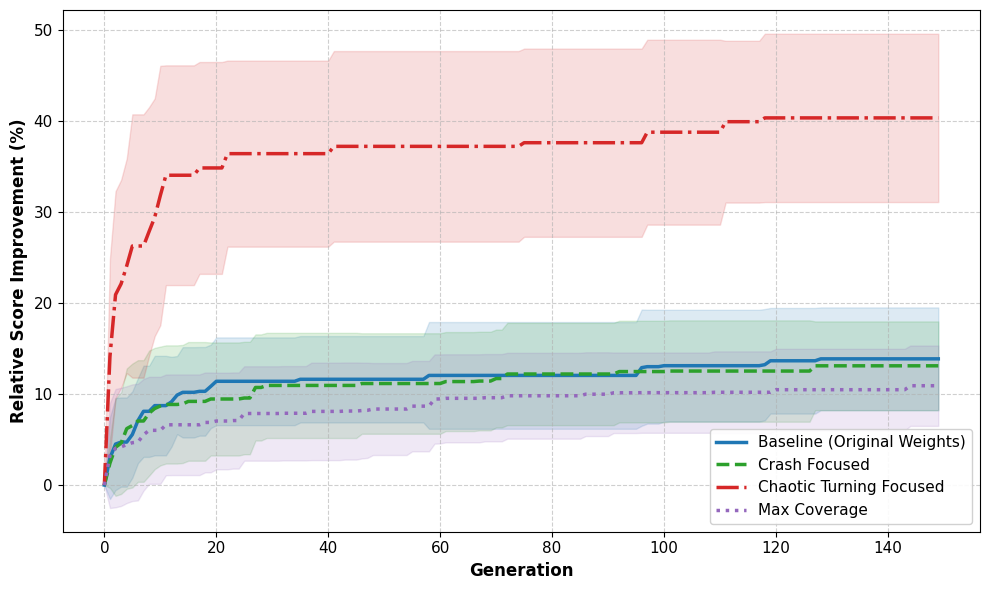

In [ ]:
# ==========================================
# 5. SENSITIVITY ANALYSIS: MULTI-SEED VALIDATION
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# Store original parameters so we can restore them later
ORIG_COVERAGE = COVERAGE_REWARD
ORIG_TURNING = TURNING_PENALTY
ORIG_CRASH = CRASH_PENALTY

# Explicitly scope and temporarily override GENERATIONS to speed up tests
global GENERATIONS
ORIG_GENS = GENERATIONS
GENERATIONS = 150 

# 1. Define Weight Configurations to Test
# Updated 'Baseline' to 'Score'
weight_profiles = {
    "Baseline (Original Weights)":  {"cov": 500.0, "turning": -100.0, "crash": -2000.0},
    "Crash Focused":                {"cov": 500.0, "turning": -100.0, "crash": -4000.0},
    "Chaotic Turning Focused":      {"cov": 500.0, "turning": -500.0, "crash": -2000.0},
    "Max Coverage":                 {"cov": 2000.0, "turning": -100.0, "crash": -2000.0}
}

# 2. Setup the Test Subject (Zone 1)
test_zone_index = 0
test_zone_mask = final_zones[test_zone_index]
corners = find_zone_corners(test_zone_mask)
corner_distances = [(get_dijkstra_distance(room_grid, MANIFOLD_POS, c), c) for c in corners]
corner_distances.sort(key=lambda x: x[0])
test_start_pos = corner_distances[0][1]

# Execution Parameters
N_RUNS = 10  # Number of Monte Carlo seeds per profile

# Store 2D array of histories: [run1_history, run2_history, ...]
sensitivity_results = {name: [] for name in weight_profiles.keys()}

print(f"Starting Multi-Seed Sensitivity Analysis ({N_RUNS} runs per profile) over {GENERATIONS} generations...")

# 3. Execution Loop
for profile_name, weights in weight_profiles.items():
    print(f"\n Testing Profile: {profile_name} ")
    
    # Dynamically update global variables
    global COVERAGE_REWARD, TURNING_PENALTY, CRASH_PENALTY
    COVERAGE_REWARD = weights["cov"]
    TURNING_PENALTY = weights["turning"]
    CRASH_PENALTY = weights["crash"]
    
    for run in range(N_RUNS):
        print(f"Run {run + 1}/{N_RUNS}...", end="\r")
        # Run the EA with the new weights
        score, px, py, history = run_zoned_evolution(room_grid, test_zone_mask, test_start_pos)
        
        # PERCENTAGE FIX: Calculate percentage improvement relative to starting score
        start_score = history[0]
        if start_score == 0: start_score = 0.0001 # Prevent division by zero just in case
        normalized_history = [((s - start_score) / abs(start_score)) * 100 for s in history]
        
        sensitivity_results[profile_name].append(normalized_history)
    print(f"Run {N_RUNS}/{N_RUNS} completed.")

# 4. Restore Original Parameters
COVERAGE_REWARD = ORIG_COVERAGE
TURNING_PENALTY = ORIG_TURNING
CRASH_PENALTY = ORIG_CRASH
GENERATIONS = ORIG_GENS

# ==========================================
# 5. Visualize the Comparison (Academic Print Format)
# ==========================================
plt.figure(figsize=(10, 6))

# Use distinct colors AND linestyles for colorblind accessibility
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
line_styles = ['-', '--', '-.', ':']

for i, (profile_name, runs_data) in enumerate(sensitivity_results.items()):
    # Convert list of lists to numpy array for easy statistical operations
    runs_array = np.array(runs_data)
    
    # Calculate Mean and Standard Deviation
    mean_history = np.mean(runs_array, axis=0)
    std_history = np.std(runs_array, axis=0)
    
    # Dynamically generate the X-axis to match the actual history length
    generations_x = np.arange(len(mean_history))
    
    # Plot the Mean as a solid/styled line
    plt.plot(generations_x, mean_history, label=f"{profile_name}", 
             color=colors[i], linestyle=line_styles[i], linewidth=2.5)
    
    # Fill the standard deviation variance band
    plt.fill_between(generations_x, 
                     mean_history - std_history, 
                     mean_history + std_history, 
                     color=colors[i], alpha=0.15)

# Formatting for report readability
plt.xlabel("Generation", fontsize=12, fontweight='bold')
# Y-AXIS LABEL UPDATE
plt.ylabel("Relative Score Improvement (%)", fontsize=12, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.show()

# Sensitivty Analysis
### Population analysis 

In [9]:
# ==========================================
# SENSITIVITY ANALYSIS: POPULATION SIZE
# ==========================================

# Store original parameters so we can restore them later
global GENERATIONS, POP_SIZE
ORIG_GENS = GENERATIONS
ORIG_POP = POP_SIZE

# Explicitly override GENERATIONS to speed up tests
GENERATIONS = 150 

# 1. Define Population Sizes to Test
pop_profiles = {
    "Pop Size: 25 (Fast/Low Diversity)": 25,
    "Pop Size: 50 (Moderate)": 50,
    "Pop Size: 100 (Baseline)": 100,
    "Pop Size: 200 (Slow/High Diversity)": 200
}

# 2. Setup the Test Subject (Zone 1)
test_zone_index = 0
test_zone_mask = final_zones[test_zone_index]
corners = find_zone_corners(test_zone_mask)
corner_distances = [(get_dijkstra_distance(room_grid, MANIFOLD_POS, c), c) for c in corners]
corner_distances.sort(key=lambda x: x[0])
test_start_pos = corner_distances[0][1]

# Execution Parameters
N_RUNS = 10  # Number of Monte Carlo seeds per profile

# Store 2D array of histories: [run1_history, run2_history, ...]
pop_sensitivity_results = {name: [] for name in pop_profiles.keys()}

print(f"Starting Multi-Seed Population Analysis ({N_RUNS} runs per profile) over {GENERATIONS} generations...")

# 3. Execution Loop
for profile_name, p_size in pop_profiles.items():
    print(f"\n Testing Profile: {profile_name} ")
    
    # Dynamically update global POP_SIZE
    POP_SIZE = p_size
    
    for run in range(N_RUNS):
        print(f"Run {run + 1}/{N_RUNS}...", end="\r")
        # Run the EA with the new population size
        score, px, py, history = run_zoned_evolution(room_grid, test_zone_mask, test_start_pos)
        
        # Calculate percentage improvement relative to starting score
        start_score = history[0]
        if start_score == 0: start_score = 0.0001 
        normalized_history = [((s - start_score) / abs(start_score)) * 100 for s in history]
        
        pop_sensitivity_results[profile_name].append(normalized_history)
    print(f"Run {N_RUNS}/{N_RUNS} completed.")

# 4. Restore Original Parameters
POP_SIZE = ORIG_POP
GENERATIONS = ORIG_GENS

# ==========================================
# 5. Visualize the Comparison (Academic Print Format)
# ==========================================
plt.figure(figsize=(10, 6))

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
line_styles = ['-', '--', '-.', ':']

for i, (profile_name, runs_data) in enumerate(pop_sensitivity_results.items()):
    runs_array = np.array(runs_data)
    
    mean_history = np.mean(runs_array, axis=0)
    std_history = np.std(runs_array, axis=0)
    generations_x = np.arange(len(mean_history))
    
    plt.plot(generations_x, mean_history, label=f"{profile_name}", 
             color=colors[i], linestyle=line_styles[i], linewidth=2.5)
    
    plt.fill_between(generations_x, 
                     mean_history - std_history, 
                     mean_history + std_history, 
                     color=colors[i], alpha=0.15)

# Formatting
plt.xlabel("Generation", fontsize=12, fontweight='bold')
plt.ylabel("Relative Score Improvement (%)", fontsize=12, fontweight='bold')
plt.title("Evolutionary Convergence by Population Size", fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.show()

NameError: name 'final_zones' is not defined

# Solving space Reduction showcase

Solving Base 4x4 Abstract Path...


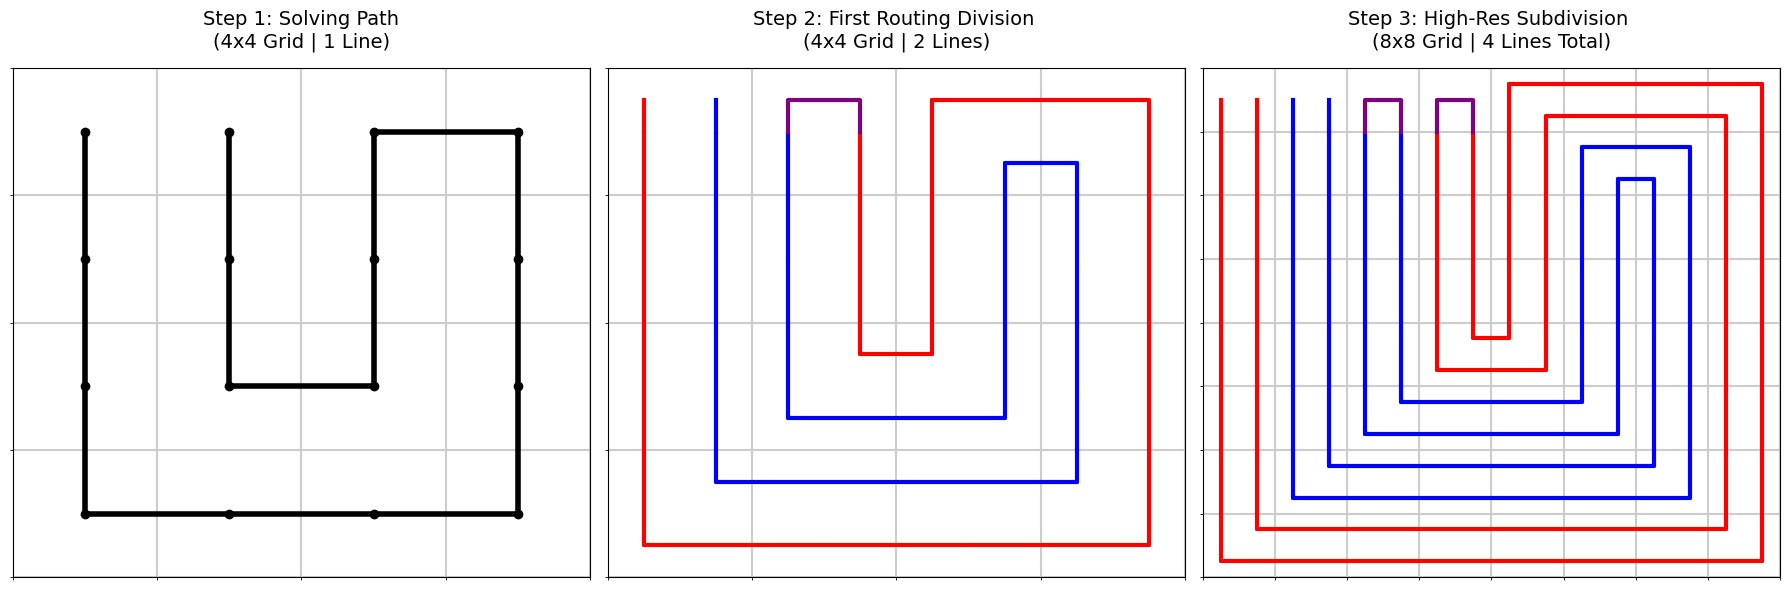

In [8]:

# ==========================================
# 1. EA PARAMETERS & HEURISTICS
# ==========================================
POP_SIZE = 150
GENERATIONS = 300
COVERAGE_REWARD = 500.0
TURNING_PENALTY = -500.0   
CRASH_PENALTY = -2000.0
STRAIGHT_RUN_BONUS = 80.0   
COMPACT_TURN_REWARD = 400.0 

# ==========================================
# 2. THE SERPENTINE SOLVER
# ==========================================
def calculate_serpentine_fitness(dna_map, base_grid, start_pos):
    grid_size = base_grid.shape[0]
    visited = np.zeros((grid_size, grid_size), dtype=bool) 
    visited[start_pos] = True 
    
    current_pos = start_pos
    path_x, path_y = [current_pos[1]], [current_pos[0]]
    score, mistakes, distance_since_last_turn = 1000.0, 0, 0 
    current_heading, previous_heading = None, None
    
    while True:
        r, c = current_pos
        valid_neighbors = []
        for heading, (dr, dc) in enumerate([(-1,0), (0,1), (1,0), (0,-1)]):
            nr, nc = r + dr, c + dc
            if 0 <= nr < grid_size and 0 <= nc < grid_size and not visited[nr, nc]:
                valid_neighbors.append(((nr, nc), heading))
                    
        if not valid_neighbors: break
            
        highest_priority = -1.0
        best_neighbor, best_heading = None, None
        for (nr, nc), heading in valid_neighbors:
            if dna_map[nr, nc] > highest_priority:
                highest_priority, best_neighbor, best_heading = dna_map[nr, nc], (nr, nc), heading

        if current_heading is not None:
            if best_heading == current_heading:
                distance_since_last_turn += 1
                score += STRAIGHT_RUN_BONUS * distance_since_last_turn
                if distance_since_last_turn > 4 and mistakes > 0:
                    mistakes -= 1; distance_since_last_turn = 0
            else:
                if distance_since_last_turn < 2: score += TURNING_PENALTY 
                if previous_heading is not None:
                    if distance_since_last_turn == 0 and abs(best_heading - previous_heading) == 2:
                        score += COMPACT_TURN_REWARD
                distance_since_last_turn = 0
                if abs(best_heading - current_heading) == 2:
                    score += CRASH_PENALTY; mistakes += 1
                previous_heading = current_heading 
                
            if mistakes >= 3: break 

        current_heading = best_heading
        current_pos = best_neighbor
        visited[current_pos] = True
        path_x.append(current_pos[1]); path_y.append(current_pos[0])
        score += COVERAGE_REWARD 
        
    return int(score), path_x, path_y

def run_showcase_evolution(grid_size):
    base_grid = np.zeros((grid_size, grid_size))
    start_pos = (0, 0)
    
    population = [np.random.rand(grid_size, grid_size) for _ in range(POP_SIZE)]
    best_score, best_px, best_py = -9999, [], []
    
    for gen in range(GENERATIONS):
        scored = []
        for dna in population:
            s, px, py = calculate_serpentine_fitness(dna, base_grid, start_pos)
            scored.append((s, dna, px, py))
            
        scored.sort(key=lambda x: x[0], reverse=True)
        if scored[0][0] > best_score:
            best_score, best_px, best_py = scored[0][0], scored[0][2], scored[0][3]
            
        parents = [s[1] for s in scored[:20]]
        next_gen = parents[:5] 
        while len(next_gen) < POP_SIZE:
            p1, p2 = random.choice(parents), random.choice(parents)
            child = np.where(np.random.rand(grid_size, grid_size) > 0.5, p1, p2)
            
            # Swap Mutation for straight behavior
            if random.random() < 0.2:
                r1, c1 = random.randint(0, grid_size-1), random.randint(0, grid_size-1)
                r2, c2 = random.randint(0, grid_size-1), random.randint(0, grid_size-1)
                child[r1, c1], child[r2, c2] = child[r2, c2], child[r1, c1]
                
            next_gen.append(child)
        population = next_gen
    return best_px, best_py

# ==========================================
# 3. GEOMETRY FUNCTIONS
# ==========================================
def clean_path(px, py):
    cx, cy = [px[0]], [py[0]]
    for i in range(1, len(px)):
        if px[i] != cx[-1] or py[i] != cy[-1]:
            cx.append(px[i]); cy.append(py[i])
    return cx, cy

def get_simple_mitered_pipe(px, py, offset):
    n = len(px)
    sx, sy = np.zeros(n), np.zeros(n)
    for i in range(n):
        if i == 0: dx, dy = px[1]-px[0], py[1]-py[0]
        elif i == n-1: dx, dy = px[-1]-px[-2], py[-1]-py[-2]
        else: dx, dy = (px[i]-px[i-1] + px[i+1]-px[i]) / 2.0, (py[i]-py[i-1] + py[i+1]-py[i]) / 2.0
            
        l = np.hypot(dx, dy)
        if l == 0: nx, ny = 0, 0
        else:
            nx, ny = -dy/l, dx/l 
            if 0 < i < n-1:
                if (1/l) > 1.5: nx *= 1.5; ny *= 1.5
                else: nx *= (1/l); ny *= (1/l)
                    
        sx[i], sy[i] = px[i] + nx * offset, py[i] + ny * offset
    return sx, sy

def draw_mitered_lines(ax, px, py, offset, color):
    sx, sy = get_simple_mitered_pipe(px, py, offset)
    segs = [[(sx[j], sy[j]), (sx[j+1], sy[j+1])] for j in range(len(sx)-1)]
    ax.add_collection(LineCollection(segs, colors=color, linewidths=3, capstyle='round'))
    return sx, sy


# ==========================================
# 4. EXECUTE & RENDER SHOWCASE (FINAL)
# ==========================================

print("Solving Base 4x4 Abstract Path...")
px_4, py_4 = run_showcase_evolution(4)
px_4, py_4 = clean_path(px_4, py_4)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
titles = [
    "Step 1: Solving Path\n(4x4 Grid | 1 Line)", 
    "Step 2: First Routing Division \n(4x4 Grid | 2 Lines)", 
    "Step 3: High-Res Subdivision \n(8x8 Grid | 4 Lines Total)"
]
axes = [ax1, ax2, ax3]

for i, ax in enumerate(axes):
    tick_spacing = 1.0 if i < 2 else 0.5 
    
    ax.set_title(titles[i], fontsize=14, pad=15)
    ax.set_xticks(np.arange(-0.5, 4, tick_spacing), minor=True)
    ax.set_yticks(np.arange(-0.5, 4, tick_spacing), minor=True)
    ax.grid(which="minor", color="#cccccc", linestyle='-', linewidth=1.5)
    
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.invert_yaxis() 

# ---------------------------------------------------------
# Vector Math for "Middle of the Cell" Extensions
# ---------------------------------------------------------
# Calculate start direction (to push entries backwards)
dx_start, dy_start = px_4[1] - px_4[0], py_4[1] - py_4[0]
l_start = np.hypot(dx_start, dy_start)
ux_start, uy_start = dx_start/l_start, dy_start/l_start

# Calculate end direction (to push U-turns outwards)
dx_end, dy_end = px_4[-1] - px_4[-2], py_4[-1] - py_4[-2]
l_end = np.hypot(dx_end, dy_end)
ux_end, uy_end = dx_end/l_end, dy_end/l_end

ext = 0.25 # Extrude exactly halfway into the next tile space

# ---------------------------------------------------------
# Plot 1: Standard Center Line
# ---------------------------------------------------------
ax1.plot(px_4, py_4, color='black', linewidth=4, marker='o', markersize=6)

# ---------------------------------------------------------
# Plot 2: Supply and Return Offsets (4x4)
# ---------------------------------------------------------
s_x4, s_y4 = draw_mitered_lines(ax2, px_4, py_4, 0.25, 'red')   
r_x4, r_y4 = draw_mitered_lines(ax2, px_4, py_4, -0.25, 'blue') 

# Entry extensions backwards
ax2.plot([s_x4[0] - ext*ux_start, s_x4[0]], [s_y4[0] - ext*uy_start, s_y4[0]], color='red', linewidth=3)
ax2.plot([r_x4[0] - ext*ux_start, r_x4[0]], [r_y4[0] - ext*uy_start, r_y4[0]], color='blue', linewidth=3)

# Single Loop U-turn connection extended outwards
ax2.plot([s_x4[-1], s_x4[-1] + ext*ux_end, r_x4[-1] + ext*ux_end, r_x4[-1]], 
         [s_y4[-1], s_y4[-1] + ext*uy_end, r_y4[-1] + ext*uy_end, r_y4[-1]], 
         color='purple', linewidth=3) 

# ---------------------------------------------------------
# Plot 3: Subdivided Offsets (8x8 simulation)
# ---------------------------------------------------------
s1_x, s1_y = draw_mitered_lines(ax3, px_4, py_4, 0.375, 'red')   
s2_x, s2_y = draw_mitered_lines(ax3, px_4, py_4, 0.125, 'red') 
r1_x, r1_y = draw_mitered_lines(ax3, px_4, py_4, -0.125, 'blue') 
r2_x, r2_y = draw_mitered_lines(ax3, px_4, py_4, -0.375, 'blue') 

# 1. Entry extensions backwards (NO CROSS CONNECTION)
lines = [(s1_x, s1_y, 'red'), (s2_x, s2_y, 'red'), (r1_x, r1_y, 'blue'), (r2_x, r2_y, 'blue')]
for lx, ly, c in lines:
    ax3.plot([lx[0] - ext*ux_start, lx[0]], [ly[0] - ext*uy_start, ly[0]], color=c, linewidth=3)

# 2. Outer Supply connects to Inner Supply (U-turn extended outwards)
ax3.plot([s1_x[-1], s1_x[-1] + ext*ux_end, s2_x[-1] + ext*ux_end, s2_x[-1]], 
         [s1_y[-1], s1_y[-1] + ext*uy_end, s2_y[-1] + ext*uy_end, s2_y[-1]], 
         color='purple', linewidth=3) 

# 3. Inner Return connects to Outer Return (U-turn extended outwards)
ax3.plot([r1_x[-1], r1_x[-1] + ext*ux_end, r2_x[-1] + ext*ux_end, r2_x[-1]], 
         [r1_y[-1], r1_y[-1] + ext*uy_end, r2_y[-1] + ext*uy_end, r2_y[-1]], 
         color='purple', linewidth=3) 

plt.tight_layout()
plt.show()